# Preparación del dataset para modelado

**TFM:** estimación de riesgo de mercado con Machine Learning.

Este notebook prepara el dataset definitivo para **entrenar y evaluar** modelos más adelante.

- **Entrada:** `data/processed/dataset_with_target.csv` (no se modifica).
- **Salida:** particiones train / validation / test y listado de features en `data/processed/modeling/`.

**No** se entrenan modelos aquí. **No** se escalan variables ni se hace tuning.


## 0. Librerías y rutas


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_with_target.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Entrada:", INPUT_PATH.resolve())
print("Salida :", OUTPUT_DIR.resolve())


Entrada: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/dataset_with_target.csv
Salida : /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/modeling


## 1. Cargar y revisar el dataset con target

Comprobaciones básicas de calidad del panel diario.


In [2]:
df = pd.read_csv(INPUT_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Filas:", len(df))
print("Columnas:", len(df.columns))
print("Fecha inicial:", df["date"].min().date())
print("Fecha final:", df["date"].max().date())
print("¿Fechas duplicadas?:", df["date"].duplicated().any())
print("¿Columna 'date' es datetime?:", pd.api.types.is_datetime64_any_dtype(df["date"]))
print("¿Orden temporal ascendente?:", df["date"].is_monotonic_increasing)

display(df.head(3))


Filas: 9139
Columnas: 34
Fecha inicial: 1990-01-02
Fecha final: 2026-04-16
¿Fechas duplicadas?: False
¿Columna 'date' es datetime?: True
¿Orden temporal ascendente?: True


,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y,future_drawdown_20d,future_vol_20d_ann,target_drawdown_20d_5,target_volatility_20d_20,target_risk_20d
0,1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,...,NaN,NaN,NaN,NaN,0,-0.102060,0.147984,1,0,1
1,1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,...,NaN,NaN,NaN,NaN,0,-0.099732,0.171083,1,0,1
2,1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,...,NaN,NaN,NaN,NaN,0,-0.091911,0.170671,1,0,1


## 2. Columnas permitidas y prohibidas (fuga de información)

Las columnas **futuras** y los **targets** no pueden usarse como features.

- **`TARGET_COL`:** variable que el modelo debe predecir.
- **`LEAKAGE_COLS`:** información del futuro o etiquetas auxiliares.
- **`date`:** se conserva para particiones y análisis, pero **no** es feature.


In [3]:
TARGET_COL = "target_risk_20d"

LEAKAGE_COLS = [
    "future_drawdown_20d",
    "future_vol_20d_ann",
    "target_drawdown_20d_5",
    "target_volatility_20d_20",
    "target_risk_20d",
]

NON_FEATURE_COLS = ["date"] + LEAKAGE_COLS

# Features: columnas numéricas que no están en NON_FEATURE_COLS
FEATURE_COLS = [
    c for c in df.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(df[c])
]

# Comprobación explícita: ninguna columna de fuga en features
leak_in_features = set(LEAKAGE_COLS) & set(FEATURE_COLS)
assert len(leak_in_features) == 0, f"Fuga detectada en FEATURE_COLS: {leak_in_features}"

print("Target principal:", TARGET_COL)
print("Número de features:", len(FEATURE_COLS))
print("\nFeatures del modelo:")
for c in FEATURE_COLS:
    print(" -", c)


Target principal: target_risk_20d
Número de features: 28

Features del modelo:
 - sp500_close
 - vix
 - treasury_10y
 - treasury_2y
 - treasury_3m
 - spread_10y_2y
 - spread_10y_3m
 - sp500_return_1d
 - sp500_return_5d
 - sp500_return_20d
 - sp500_vol_20d
 - sp500_vol_20d_ann
 - sp500_vol_60d_ann
 - sp500_rolling_max_252d
 - sp500_drawdown_252d
 - sp500_ma_50
 - sp500_ma_200
 - sp500_dist_ma50
 - sp500_dist_ma200
 - vix_change_1d
 - vix_change_5d
 - vix_ma_20
 - vix_zscore_252
 - treasury_10y_change_20d
 - treasury_2y_change_20d
 - spread_10y_2y_change_20d
 - spread_10y_3m_change_20d
 - curve_inverted_10y_2y


## 3. DataFrame de modelado (`df_model`)

Solo incluye `date`, las features permitidas y el target principal.


In [4]:
df_model = df[["date"] + FEATURE_COLS + [TARGET_COL]].copy()
print("Columnas en df_model:", len(df_model.columns))
print("Lista:", list(df_model.columns))


Columnas en df_model: 30
Lista: ['date', 'sp500_close', 'vix', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'spread_10y_2y', 'spread_10y_3m', 'sp500_return_1d', 'sp500_return_5d', 'sp500_return_20d', 'sp500_vol_20d', 'sp500_vol_20d_ann', 'sp500_vol_60d_ann', 'sp500_rolling_max_252d', 'sp500_drawdown_252d', 'sp500_ma_50', 'sp500_ma_200', 'sp500_dist_ma50', 'sp500_dist_ma200', 'vix_change_1d', 'vix_change_5d', 'vix_ma_20', 'vix_zscore_252', 'treasury_10y_change_20d', 'treasury_2y_change_20d', 'spread_10y_2y_change_20d', 'spread_10y_3m_change_20d', 'curve_inverted_10y_2y', 'target_risk_20d']


## 4. Tratamiento de nulos (`dropna`)

Los nulos al inicio suelen deberse a **ventanas rolling** (medias de 50/200 días, volatilidad, z-score del VIX, etc.): hasta acumular historia, esas columnas valen NaN.

En esta primera versión **no imputamos**: eliminamos filas con nulo en cualquier feature o en el target.


In [5]:
null_pct_antes = (df_model.isna().mean() * 100).round(2)
print("Porcentaje de nulos por columna (antes de limpiar):")
display(null_pct_antes.to_frame("pct_nulos"))

filas_antes = len(df_model)
df_model = df_model.dropna().reset_index(drop=True)
filas_despues = len(df_model)
filas_eliminadas = filas_antes - filas_despues

print("\nFilas antes de limpiar:", filas_antes)
print("Filas después de limpiar:", filas_despues)
print("Filas eliminadas:", filas_eliminadas)
print("Fecha inicial después de limpiar:", df_model["date"].min().date())
print("Fecha final después de limpiar:", df_model["date"].max().date())


Porcentaje de nulos por columna (antes de limpiar):


,pct_nulos
date,0.00
sp500_close,0.00
vix,0.00
treasury_10y,0.00
treasury_2y,0.00
treasury_3m,0.00
spread_10y_2y,0.00
spread_10y_3m,0.00
sp500_return_1d,0.01
sp500_return_5d,0.05



Filas antes de limpiar: 9139
Filas después de limpiar: 8888
Filas eliminadas: 251
Fecha inicial después de limpiar: 1990-12-28
Fecha final después de limpiar: 2026-04-16


## 5. Partición temporal train / validation / test

**No** usamos partición aleatoria: el mercado es una serie temporal.

Constantes de corte y **gap de purga** (`HORIZON_DAYS`): tras cada frontera, se excluyen 20 días para reducir solapamiento entre ventanas futuras del target (20 días de horizonte).


In [6]:
TRAIN_END = "2015-12-31"
VAL_END = "2019-12-31"
HORIZON_DAYS = 20
USE_PURGE_GAP = True

train_end = pd.Timestamp(TRAIN_END)
val_end = pd.Timestamp(VAL_END)


def first_row_after_purge_gap(df_sorted, cutoff_date, horizon_days, use_gap):
    """
    Devuelve el índice (posición) de la primera fila usable después de cutoff_date.
    Si use_gap=True, salta las siguientes `horizon_days` filas disponibles tras el corte.
    """
    after = df_sorted.index[df_sorted["date"] > cutoff_date].tolist()
    if len(after) == 0:
        return None
    if use_gap:
        if len(after) <= horizon_days:
            return None
        return after[horizon_days]
    return after[0]


# --- Train: hasta TRAIN_END inclusive ---
train_mask = df_model["date"] <= train_end
df_train = df_model.loc[train_mask].copy()

# --- Validation: tras gap desde TRAIN_END hasta VAL_END ---
val_start_idx = first_row_after_purge_gap(df_model, train_end, HORIZON_DAYS, USE_PURGE_GAP)
val_mask = (df_model.index >= val_start_idx) & (df_model["date"] <= val_end)
df_val = df_model.loc[val_mask].copy()

# --- Test: tras gap desde VAL_END hasta el final ---
test_start_idx = first_row_after_purge_gap(df_model, val_end, HORIZON_DAYS, USE_PURGE_GAP)
test_mask = df_model.index >= test_start_idx
df_test = df_model.loc[test_mask].copy()

print("Train:", len(df_train), "|", df_train["date"].min().date(), "->", df_train["date"].max().date())
print("Val  :", len(df_val), "|", df_val["date"].min().date(), "->", df_val["date"].max().date())
print("Test :", len(df_test), "|", df_test["date"].min().date(), "->", df_test["date"].max().date())


Train: 6302 | 1990-12-28 -> 2015-12-31
Val  : 986 | 2016-02-02 -> 2019-12-31
Test : 1560 | 2020-01-31 -> 2026-04-16


## 6. Resumen de particiones


,split,fecha_inicial,fecha_final,filas,positivos,pct_positivos,negativos,pct_negativos
0,train,1990-12-28,2015-12-31,6302,1605,25.47,4697,74.53
1,validation,2016-02-02,2019-12-31,986,136,13.79,850,86.21
2,test,2020-01-31,2026-04-16,1560,449,28.78,1111,71.22


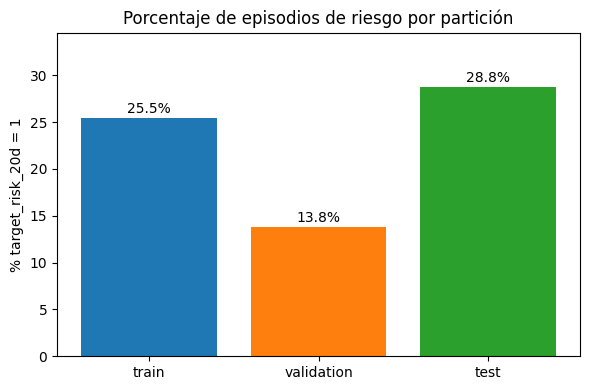

In [7]:
def split_stats(name, part_df):
    n = len(part_df)
    n_pos = int((part_df[TARGET_COL] == 1).sum())
    n_neg = n - n_pos
    return {
        "split": name,
        "fecha_inicial": part_df["date"].min().date(),
        "fecha_final": part_df["date"].max().date(),
        "filas": n,
        "positivos": n_pos,
        "pct_positivos": round(n_pos / n * 100, 2) if n else 0,
        "negativos": n_neg,
        "pct_negativos": round(n_neg / n * 100, 2) if n else 0,
    }

split_summary = pd.DataFrame([
    split_stats("train", df_train),
    split_stats("validation", df_val),
    split_stats("test", df_test),
])
display(split_summary)

# Gráfico: % de positivos por split
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split_summary["split"], split_summary["pct_positivos"], color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel("% target_risk_20d = 1")
ax.set_title("Porcentaje de episodios de riesgo por partición")
ax.set_ylim(0, max(split_summary["pct_positivos"].max() * 1.2, 5))
for i, v in enumerate(split_summary["pct_positivos"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


## 7. Matrices X e y

Preparamos arrays listos para el siguiente notebook de modelos (sin escalar todavía).


In [8]:
X_train = df_train[FEATURE_COLS].copy()
y_train = df_train[TARGET_COL].copy()

X_val = df_val[FEATURE_COLS].copy()
y_val = df_val[TARGET_COL].copy()

X_test = df_test[FEATURE_COLS].copy()
y_test = df_test[TARGET_COL].copy()

# --- Comprobaciones de seguridad ---
assert "date" not in X_train.columns
for forbidden in LEAKAGE_COLS:
    assert forbidden not in X_train.columns, f"Columna prohibida en X: {forbidden}"

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_val.isna().sum() == 0
assert y_test.isna().sum() == 0

for y_part, name in [(y_train, "train"), (y_val, "val"), (y_test, "test")]:
    assert set(y_part.unique()).issubset({0, 1}), f"y_{name} tiene valores distintos de 0/1"

print("OK: matrices X/y listas")
print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)


OK: matrices X/y listas
X_train shape: (6302, 28)
X_val shape  : (986, 28)
X_test shape : (1560, 28)


## 8. Guardar archivos procesados

Se exportan CSV con `date`, features y target. La lista de features se guarda en un `.txt` para reproducibilidad.


In [9]:
# Dataset de modelado completo (limpio)
modeling_path = OUTPUT_DIR / "modeling_dataset.csv"
df_model.to_csv(modeling_path, index=False)

# Particiones
df_train.to_csv(OUTPUT_DIR / "train.csv", index=False)
df_val.to_csv(OUTPUT_DIR / "validation.csv", index=False)
df_test.to_csv(OUTPUT_DIR / "test.csv", index=False)

# Listado de features (una por línea)
features_path = OUTPUT_DIR / "feature_columns.txt"
features_path.write_text("\n".join(FEATURE_COLS) + "\n", encoding="utf-8")

print("Archivos guardados en:", OUTPUT_DIR.resolve())
for f in sorted(OUTPUT_DIR.iterdir()):
    print(" -", f.name)


Archivos guardados en: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/modeling
 - feature_columns.txt
 - modeling_dataset.csv
 - test.csv
 - train.csv
 - validation.csv


## 9. Conclusiones

Tras ejecutar este notebook:

- El **dataset de modelado** queda sin nulos en features ni target (filas iniciales de rolling eliminadas).
- Se usan **28 features** (aprox.; ver salida de la celda 2) excluyendo `date` y columnas con información futura.
- **Excluidas por fuga:** `future_drawdown_20d`, `future_vol_20d_ann`, targets auxiliares y `target_risk_20d` como feature (solo como `y`).
- **Particiones temporales** con gap de purga de 20 días entre train→val y val→test.
- Los porcentajes de positivos por split aparecen en la tabla `split_summary` y en el gráfico de barras.

### Pendiente para el siguiente notebook

1. Escalado de features (p. ej. `StandardScaler` ajustado solo en train).
2. Entrenamiento de modelos baseline y comparativa.
3. Métricas adecuadas para clases desbalanceadas (F1, recall, ROC-AUC, etc.).
4. Validar que el pipeline no reintroduce columnas futuras.

---

## 10. Siguiente paso

Los modelos baseline se entrenan en **`notebooks/04_baseline_models.ipynb`**, usando las particiones guardadas en `data/processed/modeling/`.

*Los números concretos (filas, fechas, % positivos) se obtienen al ejecutar las celdas anteriores.*
